<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/01_linear_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 1 — Linear baseline

Start with one population-average linear relationship. Because `Days = 0` is the pre-deprivation baseline, the intercept has a direct scientific interpretation and we put its prior on that scale.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import xarray as xr
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

from pathlib import Path

NOTEBOOK = "01_linear_baseline"
FIG_DIR = Path("../../Slides/figures") if Path("../../Slides").is_dir() else Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_slide_figure(fig, section, number=None):
    """Save a Matplotlib figure or ArviZ PlotCollection for the slides."""
    suffix = f"_{number}" if number else ""
    fig.savefig(
        FIG_DIR / f"{NOTEBOOK}_{section}{suffix}.svg", bbox_inches="tight", transparent=True
    )

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


### Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

raw = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = raw.loc[raw["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


Each grey line is one participant, on the original study-day numbering. Days 0–1 were adaptation and training, day 2 is the baseline, and restriction begins after day 2.

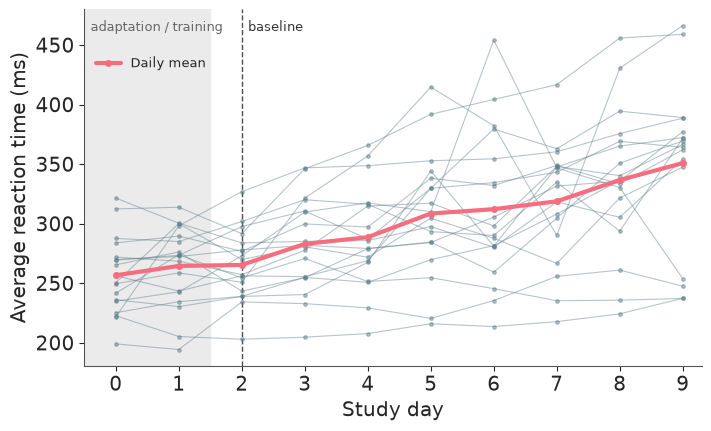

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.axvspan(-0.5, 1.5, color="0.92", zorder=0)
ax.axvline(2, color="0.3", linestyle="--", linewidth=1)
ax.text(-0.4, 0.97, "adaptation / training", transform=ax.get_xaxis_transform(),
        va="top", color="0.4", fontsize=9)
ax.text(2.1, 0.97, "baseline", transform=ax.get_xaxis_transform(),
        va="top", color="0.2", fontsize=9)
for _, person in raw.groupby("Subject"):
    ax.plot(person["Days"], person["Reaction"], color="#5f7f8a",
            marker="o", ms=2.5, lw=0.8, alpha=0.45)
daily_mean = raw.groupby("Days")["Reaction"].mean()
ax.plot(daily_mean.index, daily_mean.to_numpy(), color="C1", marker="o", ms=4, lw=3,
        label="Daily mean")
ax.set(xlabel="Study day", ylabel="Average reaction time (ms)",
       xticks=range(10), xlim=(-0.5, 9.3))
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.9), frameon=False, fontsize=9)
save_slide_figure(fig, "data")
plt.show()

### Plotting helpers

These helper functions draw the regression and its uncertainties. There are two: one for showing population regressions and one for showing individual regressions.


#### Format colors

In [5]:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)


#### plot_population

Plot any variable against days using plot_lm. Use the standard colors and legend above.

In [6]:

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={
            **LM_VISUALS,
            "xlabel": False,
            "ylabel": False,
        },
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")

    return pc

#### plot_participants

The same as plot_population but for the participants. 

In [7]:
def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

## 1.1 Prior implications

What reaction times and daily sleep-deprivation effects are plausible before seeing the data?

$$\text{Reaction}_i \sim N(\mu_i,\sigma),\qquad \mu_i=\alpha+\beta\,\text{Days}_i.$$

The priors say that baseline reaction times around a few hundred milliseconds are plausible, while the daily effect could reasonably be positive or negative before seeing the data.

In [8]:
coords = {"obs_id": np.arange(len(sleep))}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

    intercept = pm.Normal("intercept", mu=250, sigma=100)
    slope = pm.Normal("slope", mu=0, sigma=20)
    sigma = pm.Exponential("sigma", lam=0.02)

    mu = pm.Deterministic("mu", intercept + slope * days, dims="obs_id")

    pm.Normal(
        "Reaction",
        mu=mu,
        sigma=sigma,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior.

Sampling: [Reaction, intercept, sigma, slope]


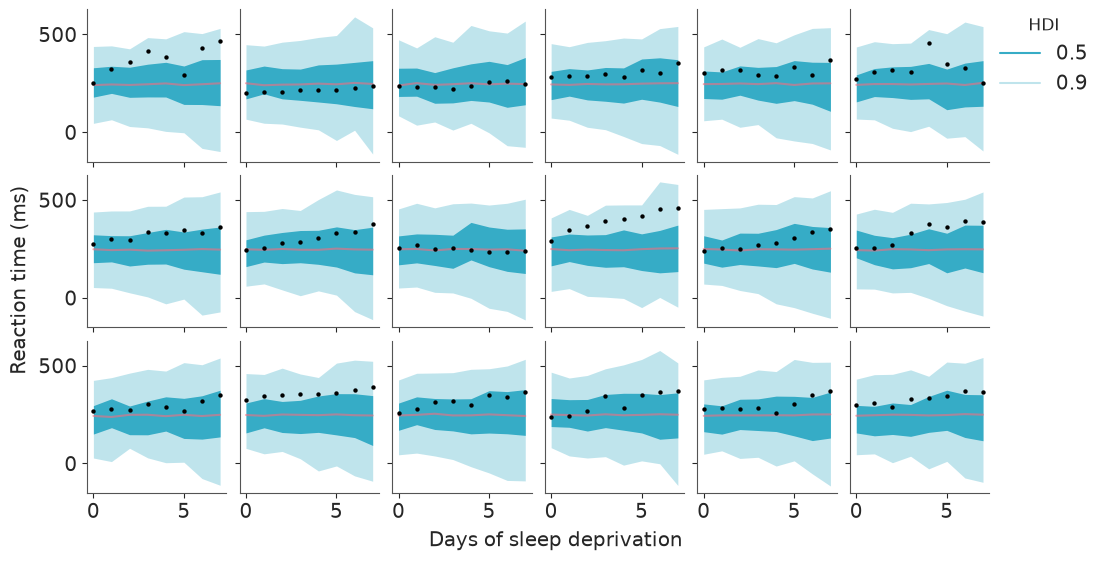

In [9]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 1.2 Population effect

What population-average change in reaction time does the data support?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [10]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.90,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata, var_names=["intercept", "slope", "sigma"],
    ci_prob=0.90, ci_kind="hdi", round_to=2,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, sigma]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 9 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,268.56,7.80,256.72,282.79,1746.64,1833.43,1.0,0.19,0.14
slope,11.25,1.87,7.94,14.07,1608.98,1796.31,1.0,0.05,0.03
sigma,51.09,3.07,46.01,55.92,2438.43,2378.80,1.0,0.06,0.06


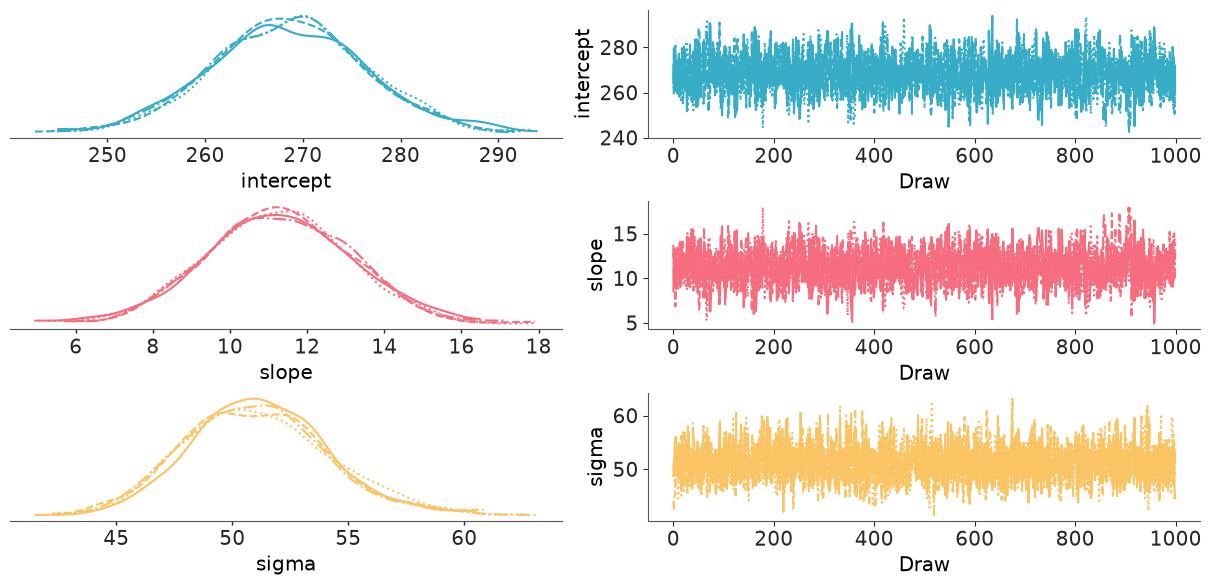

In [11]:
azp.plot_trace_dist(idata, var_names=["intercept", "slope", "sigma"]);

This plot shows posterior uncertainty in the population-average expected reaction time on each day. It does not include the variation of individual measurements.

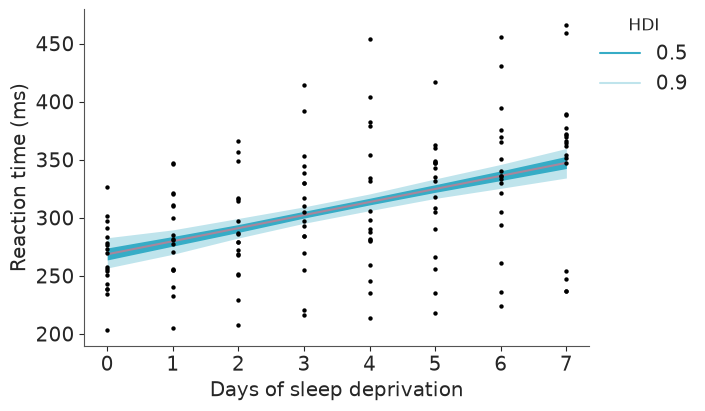

In [12]:
plot_population(idata, "mu")
plt.show()

## 1.3 Predictive adequacy

Can a single population-average line reproduce the observed reaction-time distribution?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data. The bands are the distribution of a single new measurement for each participant and day.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

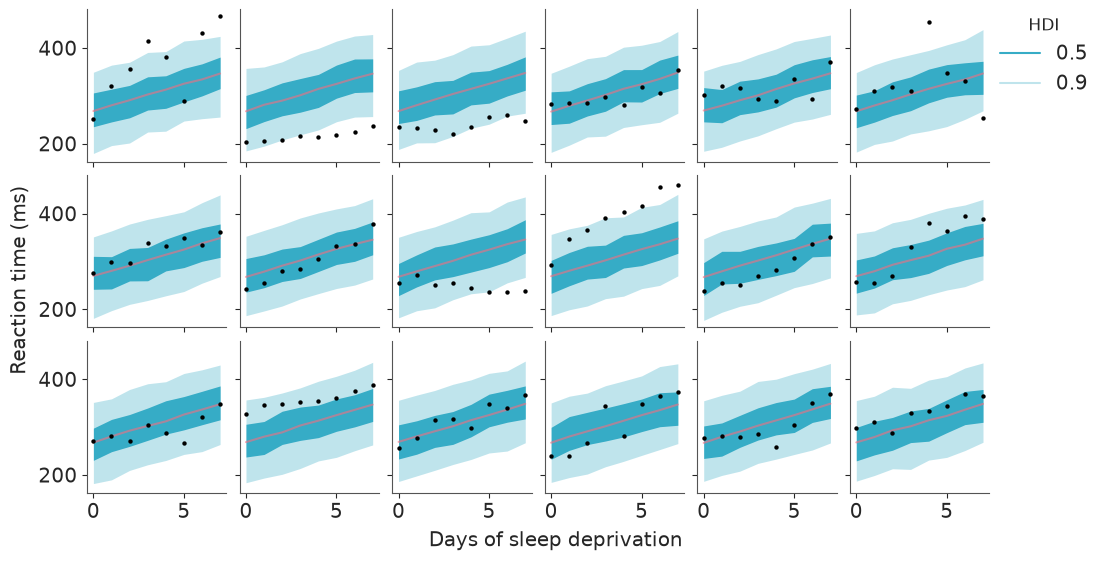

In [13]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

## 1.4 Prior sensitivity

How sensitive are the main posterior conclusions to modest changes in the priors?

The chapter uses power-scaling to ask whether modest changes in the prior would materially move the posterior.

In [14]:
with model:
    pm.compute_log_likelihood(idata)
    compute_log_density(idata, model=model, kind="prior", extend_inferencedata=True)

azs.psense_summary(idata, var_names=["intercept", "slope", "sigma"])

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

,prior,likelihood,diagnosis
intercept,0.006,0.090,✓
slope,0.007,0.086,✓
sigma,0.011,0.111,✓


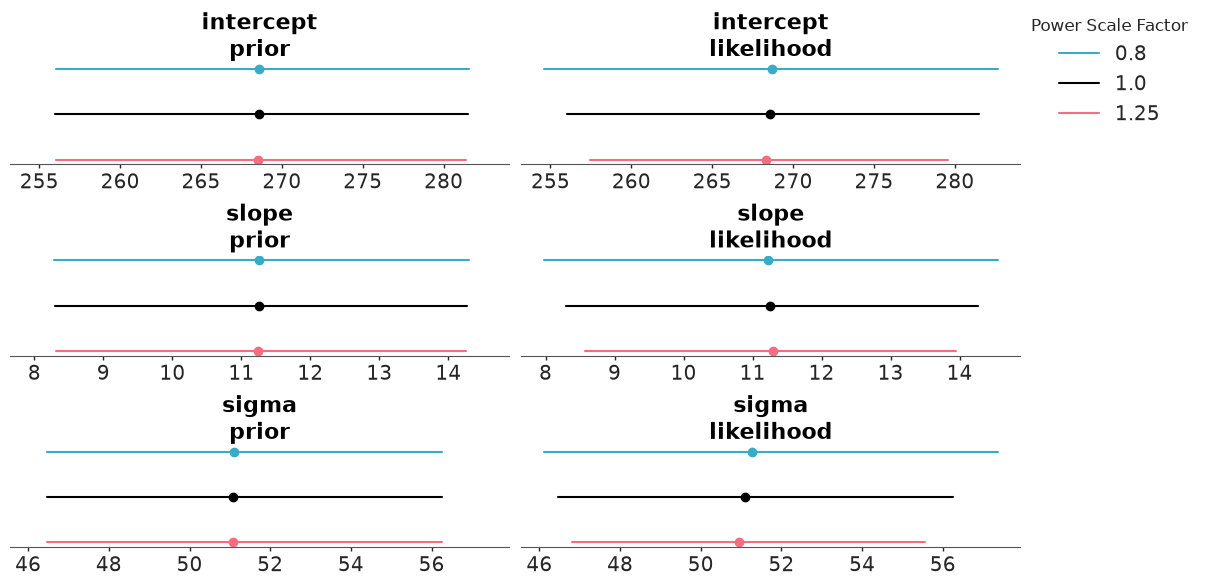

In [15]:
azp.plot_psense_dist(
    idata,
    var_names=["intercept", "slope", "sigma"],
    visuals={"dist": False},
);

## 1.5 Missing structure

What important structure in the data does this population-average model fail to represent?

The population trend is clear, but the participant panels above show whole participants sitting systematically above or below the population band — both in baseline and in trajectory shape. This model has no way to represent those between-person differences; it treats them as residual noise. The next revision adds participant-specific baseline reaction times.